<a href="https://colab.research.google.com/github/vtimkov299-alt/33105387_Database_and_Analytics_Coursework/blob/main/01_Python_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
# =========================
# PYTHON DATA PROCESSING AND ANALYTICS
# This notebook loads the Northstar logistics datasets, cleans inconsistent values,
# checks missing data, merges related files, and performs exploratory analysis using Pandas.
# =========================

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
base_path = "/content/drive/MyDrive/northstar_dataset/"

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

orders = pd.read_csv(base_path + "orders.csv")
deliveries = pd.read_csv(base_path + "deliveries.csv")
complaints = pd.read_csv(base_path + "complaints.csv")
customers = pd.read_csv(base_path + "customers.csv")
drivers = pd.read_csv(base_path + "drivers.csv")
vehicles = pd.read_csv(base_path + "vehicles.csv")
incidents = pd.read_csv(base_path + "incidents.csv")
app_events = pd.read_csv(base_path + "app_events.csv")
hubs = pd.read_csv(base_path + "hubs.csv")

In [50]:
print(orders.head())
print(deliveries.head())

  order_id customer_id service_type     order_created_at  \
0   O00001       C0292    Passenger  2024-08-20 14:43:00   
1   O00002       C0459    Passenger  2024-05-14 22:16:00   
2   O00003       C0161    Passenger  2025-09-02 14:37:00   
3   O00004       C0520       Parcel  2025-01-11 17:15:00   
4   O00005       C0558       Retail  2025-02-17 19:32:00   

   promised_window_hours pickup_zone dropoff_zone priority_level  order_value  \
0                      6     Airport        South         Medium       126.65   
1                     24       North      AIRPORT            Low       109.30   
2                      4        West      AIRPORT           High        33.50   
3                      2   RiverSide        North         Medium        10.04   
4                     12   Riverside        SOUTH            Low       125.58   

  booking_channel  special_handling_flag  
0             App                      0  
1             App                      0  
2           Phone      

In [51]:
print("Orders:", orders.shape)
print("Deliveries:", deliveries.shape)
print("Complaints:", complaints.shape)
print("Customers:", customers.shape)
print("Drivers:", drivers.shape)
print("Vehicles:", vehicles.shape)
print("Incidents:", incidents.shape)
print("App events:", app_events.shape)
print("Hubs:", hubs.shape)

Orders: (1250, 11)
Deliveries: (950, 13)
Complaints: (320, 10)
Customers: (650, 9)
Drivers: (170, 8)
Vehicles: (120, 8)
Incidents: (280, 7)
App events: (640, 10)
Hubs: (8, 5)


In [52]:
orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [53]:
deliveries.head()
complaints.head()

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18


In [54]:
# Fix text inconsistencies
deliveries['delivery_status'] = deliveries['delivery_status'].str.strip().str.lower()
complaints['severity'] = complaints['severity'].str.strip().str.lower()
orders['pickup_zone'] = orders['pickup_zone'].str.strip().str.lower()
orders['dropoff_zone'] = orders['dropoff_zone'].str.strip().str.lower()

In [55]:
datasets = {
    "orders": orders,
    "deliveries": deliveries,
    "complaints": complaints,
    "customers": customers,
    "drivers": drivers,
    "vehicles": vehicles,
    "incidents": incidents,
    "app_events": app_events,
    "hubs": hubs
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


orders
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

deliveries
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64

complaints
complaint_id            0
customer_id             0
order_id                0
complaint_type          0
channel                 0
severity                0
created_at

In [56]:
deliveries = deliveries.dropna(subset=['delivery_status'])
complaints['severity'] = complaints['severity'].fillna('unknown')

In [57]:
# Merge deliveries + orders
delivery_orders = deliveries.merge(orders, on='order_id')

# Merge complaints + orders
complaint_orders = complaints.merge(orders, on='order_id')

# Merge deliveries + drivers
delivery_driver = deliveries.merge(drivers, on='driver_id')

In [58]:
delivery_orders.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,failed,17.26,1,...,C0567,Business,2024-06-18 09:48:00,6,central,central,Medium,151.14,Web,0
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,ontime,10.34,1,...,C0520,Parcel,2025-01-11 17:15:00,2,riverside,north,Medium,10.04,App,1
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,ontime,7.92,0,...,C0480,Medical,2025-06-02 19:12:00,2,central,north,Medium,141.93,Web,0
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,delayed,16.42,0,...,C0616,Medical,2024-03-08 20:58:00,24,south,north,Low,11.11,App,0
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,ontime,14.52,1,...,C0276,Medical,2025-09-21 09:29:00,6,riverside,riverside,High,76.02,App,0


In [59]:
failure_zone = delivery_orders.groupby('pickup_zone')['delivery_status'].apply(
    lambda x: (x == 'failed').mean()
).sort_values(ascending=False)

failure_zone

,delivery_status
pickup_zone,
central,0.200000
ctr,0.171875
north,0.162963
riverside,0.151261
west,0.122807
east,0.121795
airport,0.106195
south,0.100719


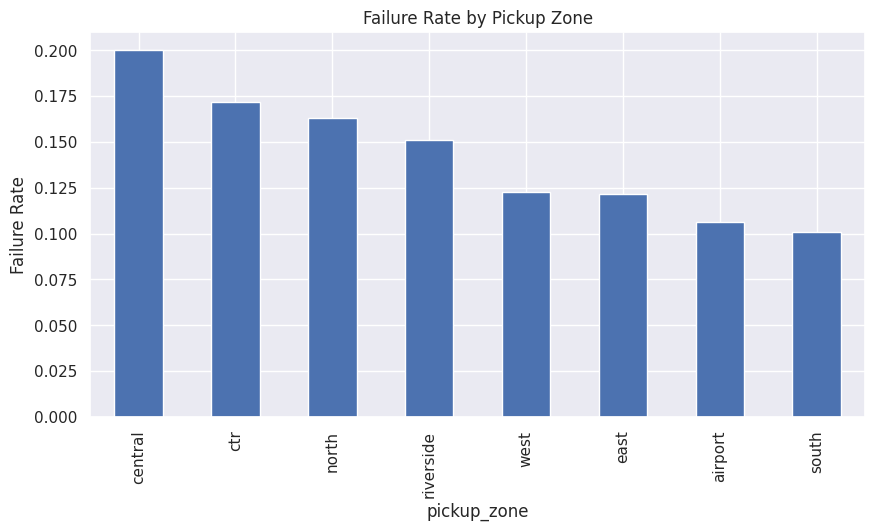

In [60]:
failure_zone.plot(kind='bar', figsize=(10,5))
plt.title('Failure Rate by Pickup Zone')
plt.ylabel('Failure Rate')
plt.show()

In [61]:
deliveries.columns = deliveries.columns.str.strip().str.lower()

print(deliveries.columns)

override_col = None

for col in deliveries.columns:
    if 'override' in col:
        override_col = col
        break

print("Using column:", override_col)

pd.crosstab(
    deliveries[override_col],
    deliveries['delivery_status'],
    normalize='index'
)

Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost'],
      dtype='object')
Using column: manual_route_override_count


delivery_status,delayed,failed,ontime
manual_route_override_count,,,
0,0.195489,0.115288,0.689223
1,0.216129,0.164516,0.619355
2,0.222222,0.143791,0.633987
3,0.245614,0.175439,0.578947
4,0.217391,0.130435,0.652174
5,0.571429,0.000000,0.428571
7,0.000000,0.000000,1.000000


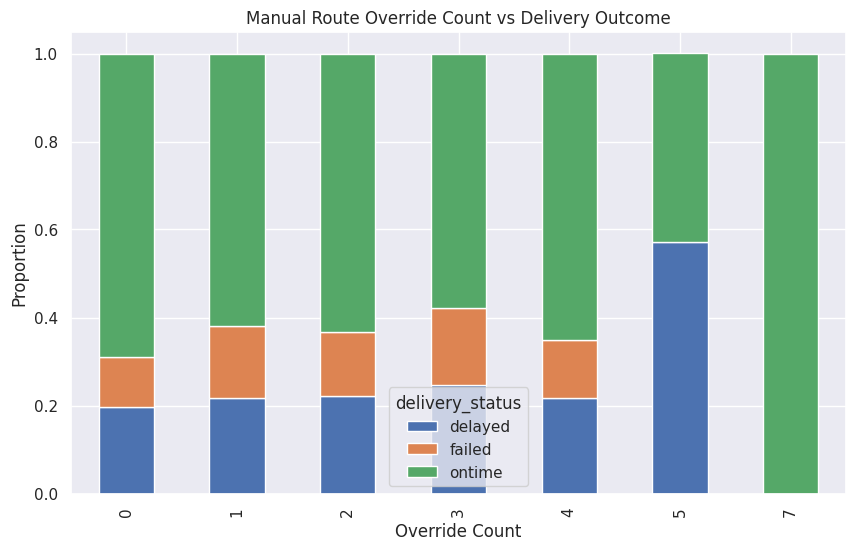

In [62]:
pd.crosstab(
    deliveries[override_col],
    deliveries['delivery_status'],
    normalize='index'
).plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Manual Route Override Count vs Delivery Outcome')
plt.ylabel('Proportion')
plt.xlabel('Override Count')
plt.show()

In [63]:
combined = deliveries.merge(complaints, on='order_id', how='left')

combined.groupby('manual_route_override_count')['severity'].value_counts(normalize=True)

manual_route_override_count  severity
0                            medium      0.524272
                             high        0.262136
                             low         0.213592
1                            medium      0.661972
                             high        0.197183
                             low         0.140845
2                            medium      0.600000
                             low         0.275000
                             high        0.125000
3                            high        0.428571
                             medium      0.428571
                             low         0.142857
4                            high        0.333333
                             low         0.333333
                             medium      0.333333
5                            medium      1.000000
Name: proportion, dtype: float64

In [64]:
delivery_driver = deliveries.merge(drivers, on='driver_id')

delivery_driver.groupby('training_score')['delivery_status'].value_counts(normalize=True)

training_score  delivery_status
40.6            ontime             0.714286
                delayed            0.142857
                failed             0.142857
41.4            ontime             0.600000
                delayed            0.200000
                                     ...   
98.7            delayed            0.333333
                failed             0.111111
99.0            ontime             0.500000
                failed             0.300000
                delayed            0.200000
Name: proportion, Length: 290, dtype: float64

In [65]:
vehicle_data = deliveries.merge(vehicles, on='vehicle_id')

vehicle_data.groupby('vehicle_type')['delivery_status'].value_counts(normalize=True)

vehicle_type  delivery_status
CargoVan      ontime             0.591928
              delayed            0.237668
              failed             0.170404
Diesel        ontime             0.659722
              failed             0.180556
              delayed            0.159722
EV            ontime             0.693215
              delayed            0.218289
              failed             0.088496
Hybrid        ontime             0.631148
              delayed            0.213115
              failed             0.155738
Name: proportion, dtype: float64

In [66]:
incident_data = incidents.merge(deliveries, on='delivery_id')

incident_data['incident_type'].value_counts()

,count
incident_type,
ProofMissing,46
CustomerNoShow,44
RouteDeviation,43
VehicleFault,37
BatteryAlert,36
AppSyncError,31
TemperatureIssue,29
SafetyNearMiss,14


In [67]:
complaints['complaint_type'].value_counts()

,count
complaint_type,
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15
